In [1]:
from pathlib import Path
from textalloc import allocate
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import yaml

from _configs.country_config import *
from _configs.files_config import *
from _configs.run_config import *

from _utils.utils import *

In [2]:
input_data = yaml.safe_load((Path(VALIDATION_RUN_INPUTS_DIR)/"input_validation.yml").read_text(encoding="utf-8"))
# input_data = yaml.safe_load((Path(VALIDATION_RUN_INPUTS_DIR)/"input_population_bins_beta_zero_pop_0.25.yml").read_text(encoding="utf-8"))


population_scale_from_input_yml = input_data["population_demographic"]["artificial_rescaling_of_population_size"]
starting_date = input_data["simulation_timeframe"]["starting_date"]
birth_rate_from_config = input_data["population_demographic"]["birth_rate"]
public_pct = input_data["strategy_parameters"]["strategy_db"][8]["start_distribution"][0]
private_pct = input_data["strategy_parameters"]["strategy_db"][8]["start_distribution"][1]

print(f"Population scale: {population_scale_from_input_yml}")
print(f"Starting date: {starting_date}")
print(f"Birth rate: {birth_rate_from_config}")
print(f"Public percentage: {public_pct}")
print(f"Private percentage: {private_pct}")

# 1) Use the original dict
country_dict = {
    "population_scale": population_scale_from_input_yml,
    }
country_json = json.dumps(country_dict, ensure_ascii=False)
# 3) Attribute-style access (SimpleNamespace)
from types import SimpleNamespace
country = json.loads(country_json, object_hook=lambda d: SimpleNamespace(**d))

exp_path = validation_path
output_path = Path(exp_path) / "output"
analysis_path = Path(exp_path) / "analysis"
os.makedirs(analysis_path, exist_ok=True)

print("\ndata_path:", data_path)
print("output_path:", output_path)
print("analysis_path:", analysis_path)

Population scale: 0.25
Starting date: 2011/1/1
Birth rate: 0.0335
Public percentage: 0.445
Private percentage: 0.555

data_path: DATA
output_path: validation_runs/validation_init_pop_21.12M.asc_0.25_population_scale_one_pattern_20_replicates/output
analysis_path: validation_runs/validation_init_pop_21.12M.asc_0.25_population_scale_one_pattern_20_replicates/analysis


## PfPR

In [3]:
output_path_obj = Path(output_path)
if not output_path_obj.exists() or not output_path_obj.is_dir():
    raise NotADirectoryError(f"Path {output_path} is not a valid directory.")
db_files = list(output_path_obj.glob("*.db"))
if len(db_files) == 0:
    raise FileNotFoundError(f"No .db files found in directory {output_path}.")

agg_population = pd.DataFrame(columns=["monthly_data_id", "unit_id", "population"])
agg_treatment = pd.DataFrame(columns=["monthly_data_id", "unit_id", "treatments"])
agg_clinical_episodes = pd.DataFrame(columns=["monthly_data_id", "unit_id", "clinical_episodes"])
agg_prevalence_2_to_10 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "pfpr_2to10"])
agg_clinical_episodes_2_to_10 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "clinical_episodes_2_to_10"])
agg_prevalence_under_5 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "pfpr_under5"])
agg_clinical_episodes_under_5 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "clinical_episodes_under5"])

rep = 0
for file in output_path_obj.glob("*.db"):
    data = get_table(file, "monthly_site_data_district")
    clinical_episodes_2_to_10 = data[
        [
            "monthly_data_id",
            "unit_id",
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
            "clinical_episodes_by_age_class_5_6",
            "clinical_episodes_by_age_class_6_7",
            "clinical_episodes_by_age_class_7_8",
            "clinical_episodes_by_age_class_8_9",
            "clinical_episodes_by_age_class_9_10",
        ]
    ].copy()
    clinical_episodes_2_to_10["clinical_episodes_2_to_10"] = clinical_episodes_2_to_10[
        [
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
            "clinical_episodes_by_age_class_5_6",
            "clinical_episodes_by_age_class_6_7",
            "clinical_episodes_by_age_class_7_8",
            "clinical_episodes_by_age_class_8_9",
            "clinical_episodes_by_age_class_9_10",
        ]
    ].sum(axis=1)
    clinical_episodes_under_5 = data[
        [
            "monthly_data_id",
            "unit_id",
            "clinical_episodes_by_age_class_0_1",
            "clinical_episodes_by_age_class_1_2",
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
        ]
    ].copy()
    clinical_episodes_under_5["clinical_episodes_under5"] = clinical_episodes_under_5[
        [
            "clinical_episodes_by_age_class_0_1",
            "clinical_episodes_by_age_class_1_2",
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
        ]
    ].sum(axis=1)
    
    # Add a column to the agg_* data frames from data
    try:
        agg_population = agg_population.merge(
            data[["monthly_data_id", "unit_id", "population"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_treatment = agg_treatment.merge(
            data[["monthly_data_id", "unit_id", "treatments"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_clinical_episodes = agg_clinical_episodes.merge(
            data[["monthly_data_id", "unit_id", "clinical_episodes"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_prevalence_2_to_10 = agg_prevalence_2_to_10.merge(
            data[["monthly_data_id", "unit_id", "pfpr_2to10"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        
        agg_clinical_episodes_2_to_10 = agg_clinical_episodes_2_to_10.merge(
            clinical_episodes_2_to_10[["monthly_data_id", "unit_id", "clinical_episodes_2_to_10"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_prevalence_under_5 = agg_prevalence_under_5.merge(
            data[["monthly_data_id", "unit_id", "pfpr_under5"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_clinical_episodes_under_5 = agg_clinical_episodes_under_5.merge(
            clinical_episodes_under_5[["monthly_data_id", "unit_id", "clinical_episodes_under5"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
    except Exception as e:
        error(f"Error processing replicate {rep}: {e}")
    rep += 1
    
agg_population = agg_population.drop(columns=["population"])
agg_treatment = agg_treatment.drop(columns=["treatments"])
agg_clinical_episodes = agg_clinical_episodes.drop(columns=["clinical_episodes"])
agg_prevalence_2_to_10 = agg_prevalence_2_to_10.drop(columns=["pfpr_2to10"])
agg_clinical_episodes_2_to_10 = agg_clinical_episodes_2_to_10.drop(columns=["clinical_episodes_2_to_10"])
agg_prevalence_under_5 = agg_prevalence_under_5.drop(columns=["pfpr_under5"])
agg_clinical_episodes_under_5 = agg_clinical_episodes_under_5.drop(columns=["clinical_episodes_under5"])

agg_prevalence_2_to_10.to_csv(f"{analysis_path}/agg_prevalence_2_to_10.csv", index=False)
agg_clinical_episodes_2_to_10.to_csv(f"{analysis_path}/agg_clinical_episodes_2_to_10.csv", index=False)
agg_prevalence_under_5.to_csv(f"{analysis_path}/agg_prevalence_under_5.csv", index=False)
agg_clinical_episodes_under_5.to_csv(f"{analysis_path}/agg_clinical_episodes_under_5.csv", index=False)
agg_population.to_csv(f"{analysis_path}/agg_population.csv", index=False)
agg_treatment.to_csv(f"{analysis_path}/agg_treatment.csv", index=False)
agg_clinical_episodes.to_csv(f"{analysis_path}/agg_clinical_episodes.csv", index=False)

In [4]:
# agg_clinical_episodes.tail(24)
# agg_clinical_episodes = agg_clinical_episodes.sort_values("unit_id", ascending=False).reset_index(drop=True)
# unit_id_to_inspect = 6
# agg_clinical_episodes.loc[
#     agg_clinical_episodes["unit_id"] == unit_id_to_inspect
# ].sort_values("monthly_data_id")
agg_clinical_episodes.tail(24)

,monthly_data_id,unit_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,...,clinical_episodes_10,clinical_episodes_11,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19
918,154,1,75016,75227,74952,75100,74246,75311,74494,75370,...,74717,74537,75604,75411,75185,74483,75139,75078,75012,75039
919,154,2,45269,45863,45618,45987,45898,46033,45845,45718,...,45447,45547,45322,45532,45561,45572,45793,46336,45458,45678
920,154,3,37667,37692,37312,37391,37401,36980,37420,37632,...,37505,37398,37388,37429,37403,37320,37304,37865,37512,37406
921,154,4,31720,31358,31290,31253,31380,31257,31257,31465,...,31370,31199,31518,31660,31017,31193,31230,31322,31569,31099
922,154,5,63200,62552,62217,62347,62843,62292,62802,63491,...,62962,62814,62508,63118,62970,62682,62595,62868,63422,62707
923,154,6,37163,37718,36798,37247,37193,37259,37657,36942,...,37315,37446,37493,37190,37386,37592,37501,37456,37235,36844
924,155,1,78078,77428,77069,77684,77230,77646,77466,77606,...,77985,77183,77991,77683,77128,77244,78015,77302,77480,77295
925,155,2,47136,47463,47383,47052,47146,47727,47054,47162,...,46479,47522,47130,47437,47032,47587,46942,47415,47321,47282
926,155,3,39023,38745,38888,38986,38815,38551,38871,38767,...,38645,38740,39004,38398,38387,38365,38640,38869,38824,38784
927,155,4,32604,32445,32566,32235,32132,32458,32322,32520,...,32395,32576,32748,32517,32531,32236,32497,32409,32659,32637


In [5]:
# print agg_clincal_episodes sorted by monthly_data_id
# print(agg_clinical_episodes.sort_values(by="monthly_data_id"))

In [6]:
# months = np.sort(agg_clinical_episodes["monthly_data_id"].unique())
# end_month = int(months[-1]) + 1
# start_month = end_month - 12

# start month should be january of incidence comparision year assuming month 0 is january of initial year
incidence_comparison_start_month = (incidence_comparison_year - initial_year) * 12
incidence_comparison_end_month = incidence_comparison_start_month + 12

print(f"Start month for incidence comparison: {incidence_comparison_start_month}, End month: {incidence_comparison_end_month}")
print(f"Start date: {initial_year + incidence_comparison_start_month // 12}-{incidence_comparison_start_month % 12 + 1:02d}")
print(f"End date: {initial_year + incidence_comparison_end_month // 12}-{incidence_comparison_end_month % 12 + 1:02d}")

Start month for incidence comparison: 120, End month: 132
Start date: 2021-01
End date: 2022-01


In [7]:
prevalence_comparison_start_month = (calibration_year - initial_year) * 12
prevalence_comparison_end_month = prevalence_comparison_start_month + 12

print(f"Start month for calibration comparison: {prevalence_comparison_start_month}, End month: {prevalence_comparison_end_month}")
print(f"Start date: {initial_year + prevalence_comparison_start_month // 12}-{prevalence_comparison_start_month % 12 + 1:02d}")
print(f"End date: {initial_year + prevalence_comparison_end_month // 12}-{prevalence_comparison_end_month % 12 + 1:02d}")

Start month for calibration comparison: 156, End month: 168
Start date: 2024-01
End date: 2025-01


In [8]:
# agg_test = pd.DataFrame(columns=["monthly_data_id", "unit_id"])
# agg_test


In [9]:
# data_test = data[
#         [
#             "monthly_data_id",
#             "unit_id",
#             "clinical_episodes",
#             "population",
#             "treatments"
#         ]    
#     ].copy()
# data_test

In [10]:
# agg_test = agg_test.merge(
#     data[["monthly_data_id", "unit_id", "clinical_episodes","population","treatments"]].copy(),
#     how="outer",
#     on=["monthly_data_id", "unit_id"],
#     suffixes=("", f"_{validation_replicates}"),
# )
# agg_test

In [11]:
# agg_test_at_calib = agg_test.loc[agg_test["monthly_data_id"].between(incidence_comparison_start_month, incidence_comparison_end_month, inclusive="left")].copy()

In [12]:
# g = agg_test_at_calib.copy().groupby("unit_id")["clinical_episodes"]

In [13]:
# for unit_id, vals in g:
#     print("unit_id:", unit_id)
#     print(vals)
#     print()

In [14]:
# agg_test_at_calib_mean_by_location = pd.DataFrame()
# agg_test_at_calib_mean_by_location["clinical_episodes_mean"] = agg_test_at_calib.copy().groupby("unit_id")["clinical_episodes"].sum()
# agg_test_at_calib_mean_by_location["population_mean"] = agg_test_at_calib.copy().groupby("unit_id")["population"].mean()
# agg_test_at_calib_mean_by_location["treatments_mean"] = agg_test_at_calib.copy().groupby("unit_id")["treatments"].sum()

In [15]:
# agg_test_at_calib_mean_by_location

In [16]:
# agg_test_at_calib_mean_by_location.sum(axis=0)

In [17]:
agg_clinical_episodes = pd.read_csv(f"{analysis_path}/agg_clinical_episodes.csv")
agg_clinical_episodes_2_to_10 = pd.read_csv(f"{analysis_path}/agg_clinical_episodes_2_to_10.csv")
agg_clinical_episodes_under_5 = pd.read_csv(f"{analysis_path}/agg_clinical_episodes_under_5.csv")
agg_prevalence_2_to_10 = pd.read_csv(f"{analysis_path}/agg_prevalence_2_to_10.csv")
agg_prevalence_under_5 = pd.read_csv(f"{analysis_path}/agg_prevalence_under_5.csv")
agg_population = pd.read_csv(f"{analysis_path}/agg_population.csv")
agg_treatment = pd.read_csv(f"{analysis_path}/agg_treatment.csv")

In [18]:
agg_clinical_episodes.tail(6)

,monthly_data_id,unit_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,...,clinical_episodes_10,clinical_episodes_11,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19
936,157,1,77809,77722,77410,77732,77409,77919,77462,77222,...,77722,78317,78169,77885,77570,77652,77989,77334,77210,77625
937,157,2,46806,47862,47155,47421,46838,47415,47370,47246,...,47383,47476,47153,47524,47128,47211,46792,47523,47623,47585
938,157,3,39258,38744,38717,38678,38596,38818,38912,39078,...,38844,38822,39160,39013,38728,38915,39350,38907,38771,38641
939,157,4,32773,32975,32427,32377,32577,32472,32415,32177,...,32357,32653,32760,32574,32928,32372,32446,32459,32425,32183
940,157,5,64942,65109,64250,65619,65529,65247,65522,64879,...,65558,65395,65273,65529,65109,64760,65216,65210,65149,65223
941,157,6,38447,38920,38737,38760,38624,38365,39221,38509,...,38833,38459,39062,38839,38853,38785,38955,38598,38196,38407


In [19]:
# data_at_calib = agg_clinical_episodes.loc[agg_population["monthly_data_id"].between(incidence_comparison_start_month, incidence_comparison_end_month, inclusive="left")].copy()
data_at_calib = agg_clinical_episodes.loc[
    agg_clinical_episodes["monthly_data_id"].between(
        incidence_comparison_start_month,
        incidence_comparison_end_month,
        inclusive="left"
    )
].copy()
data_at_calib

,monthly_data_id,unit_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,...,clinical_episodes_10,clinical_episodes_11,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19
714,120,1,70680,71361,70840,71508,71783,71023,70762,71132,...,71513,71410,71080,71421,70704,71316,71069,71719,71208,71598
715,120,2,43583,43250,43635,43487,43464,43626,43933,44045,...,43534,43382,43614,44276,43366,43392,43401,43246,43545,43235
716,120,3,35711,35524,35294,35131,35186,35916,35595,35685,...,35232,35345,35678,35409,35773,35700,35257,35212,35168,35713
717,120,4,30074,29652,30007,30291,30005,30107,29777,30228,...,29822,29783,30105,30039,30003,30176,30098,29831,30182,30532
718,120,5,59614,59797,60289,59647,59879,59876,59114,60242,...,59968,59950,59858,59234,58695,59599,59701,60203,60138,59685
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
781,131,2,45841,46010,45167,45939,45455,45842,46157,45400,...,46070,45834,45812,45868,45779,45746,45610,45513,46104,45617
782,131,3,37469,37096,37044,37356,36926,37583,37251,37412,...,36919,37126,37756,37311,37250,37158,37597,36945,37310,37684
783,131,4,31487,31332,31217,31724,31461,31798,31379,31622,...,31547,31327,31656,31218,31241,31557,31569,31113,31357,31234
784,131,5,63087,62766,62453,63149,62251,63071,63526,63430,...,63015,62714,63002,62855,62470,63010,62832,63076,62733,62694


In [20]:
# data_at_calib_sum_1_year = data_at_calib.groupby("unit_id").sum().reset_index()
# data_at_calib_sum_1_year

In [21]:
# data_at_calib_mean_all_rep_1_year = data_at_calib_sum_1_year.copy().drop(columns=["monthly_data_id"]).mean(axis=1)
# data_at_calib_mean_all_rep_1_year

In [22]:
# data_at_calib_mean_all_rep_1_year.sum()
agg_treatment.head(18)

,monthly_data_id,unit_id,treatments_0,treatments_1,treatments_2,treatments_3,treatments_4,treatments_5,treatments_6,treatments_7,...,treatments_10,treatments_11,treatments_12,treatments_13,treatments_14,treatments_15,treatments_16,treatments_17,treatments_18,treatments_19
0,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,4,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,5,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1,6,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,2,1,257624,259047,258833,257555,257071,258246,258068,258500,...,258642,258849,257211,257161,257525,257792,257424,256796,257795,257232
7,2,2,137924,137957,137368,137848,138494,138305,137805,137934,...,137611,138133,138413,138200,138517,137657,138660,137771,138284,138416
8,2,3,116040,116441,115435,115087,115922,115714,115349,115738,...,115913,115920,115267,114920,115178,115556,116073,115047,115619,115949
9,2,4,81144,80718,80576,80729,80624,80758,81002,80944,...,80930,80391,81155,80723,80369,80746,80745,80536,80869,80974


In [23]:
''' Groups the treatment data by unit_id and sums the total treatments across the specified year (start month to end month) '''
total_treatments_in_incidence_comparison_year_by_unit_id = (
    agg_treatment.loc[agg_treatment["monthly_data_id"].between(incidence_comparison_start_month, incidence_comparison_end_month, inclusive="left")]
    .copy()
    .groupby("unit_id")
    .sum()
)
total_treatments_in_incidence_comparison_year_by_unit_id

,monthly_data_id,treatments_0,treatments_1,treatments_2,treatments_3,treatments_4,treatments_5,treatments_6,treatments_7,treatments_8,...,treatments_10,treatments_11,treatments_12,treatments_13,treatments_14,treatments_15,treatments_16,treatments_17,treatments_18,treatments_19
unit_id,,,,,,,,,,,,,,,,,,,,,
1,1506,526184,526947,523551,527737,528395,523578,520868,524515,527360,...,524603,527239,526003,525425,526180,527325,527034,525943,526400,525831
2,1506,261449,260181,259810,261852,260259,261021,262705,261879,260955,...,261769,261521,260442,260209,261989,260636,260565,260151,262197,260056
3,1506,249125,249191,249394,249906,248297,249651,250897,249604,249523,...,248370,249178,251930,249221,250338,251743,249105,249743,249406,252035
4,1506,159359,158750,157401,159837,159529,159972,158429,160051,158521,...,159755,159146,158624,158756,158272,158632,158732,158694,159925,159965
5,1506,272760,272085,274871,274493,273010,273458,272706,272749,271646,...,272752,273968,273110,272419,273072,272497,273399,273295,274372,272615
6,1506,165371,165965,166775,167366,166342,165879,166820,167970,165781,...,166303,166822,167561,166082,167400,166613,168036,165967,165365,167099


In [24]:
total_treatments_in_incidence_comparison_year_by_unit_id = (
    agg_treatment.loc[agg_treatment["monthly_data_id"].between(incidence_comparison_start_month, incidence_comparison_end_month, inclusive="left")]
    .copy()
    .groupby("unit_id")
    .sum()
)
# Drop monthly data id column, this data is now showing total treatments across the specified year (start month to end month) by unit id
total_treatments_in_incidence_comparison_year_by_unit_id = total_treatments_in_incidence_comparison_year_by_unit_id.drop(columns=["monthly_data_id"])
total_treatments_in_incidence_comparison_year_by_unit_id["mean"] = total_treatments_in_incidence_comparison_year_by_unit_id.mean(axis=1)
total_treatments_in_incidence_comparison_year_by_unit_id["std"] = total_treatments_in_incidence_comparison_year_by_unit_id.std(axis=1)
total_treatments_in_incidence_comparison_year_by_unit_id


,treatments_0,treatments_1,treatments_2,treatments_3,treatments_4,treatments_5,treatments_6,treatments_7,treatments_8,treatments_9,...,treatments_12,treatments_13,treatments_14,treatments_15,treatments_16,treatments_17,treatments_18,treatments_19,mean,std
unit_id,,,,,,,,,,,,,,,,,,,,,
1,526184,526947,523551,527737,528395,523578,520868,524515,527360,524467,...,526003,525425,526180,527325,527034,525943,526400,525831,525779.25,1734.670369
2,261449,260181,259810,261852,260259,261021,262705,261879,260955,260462,...,260442,260209,261989,260636,260565,260151,262197,260056,261005.40,827.008912
3,249125,249191,249394,249906,248297,249651,250897,249604,249523,249940,...,251930,249221,250338,251743,249105,249743,249406,252035,249829.85,1039.458382
4,159359,158750,157401,159837,159529,159972,158429,160051,158521,160277,...,158624,158756,158272,158632,158732,158694,159925,159965,159131.35,742.600247
5,272760,272085,274871,274493,273010,273458,272706,272749,271646,273973,...,273110,272419,273072,272497,273399,273295,274372,272615,273162.50,809.905951
6,165371,165965,166775,167366,166342,165879,166820,167970,165781,167213,...,167561,166082,167400,166613,168036,165967,165365,167099,166636.50,783.235437


In [25]:
total_clinical_episodes_in_incidence_comparison_year_by_unit_id = (
    agg_clinical_episodes.loc[agg_clinical_episodes["monthly_data_id"].between(incidence_comparison_start_month, incidence_comparison_end_month, inclusive="left")]
    .copy()
    .groupby("unit_id")
    .sum()
)
total_clinical_episodes_in_incidence_comparison_year_by_unit_id = total_clinical_episodes_in_incidence_comparison_year_by_unit_id.drop(columns=["monthly_data_id"])
# mean_clinical_episodes = mean_clinical_episodes.drop(columns=["clinical_episodes"])
total_clinical_episodes_in_incidence_comparison_year_by_unit_id["mean"] = total_clinical_episodes_in_incidence_comparison_year_by_unit_id.mean(axis=1)
total_clinical_episodes_in_incidence_comparison_year_by_unit_id["std"] = total_clinical_episodes_in_incidence_comparison_year_by_unit_id.std(axis=1)
total_clinical_episodes_in_incidence_comparison_year_by_unit_id

,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,clinical_episodes_8,clinical_episodes_9,...,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19,mean,std
unit_id,,,,,,,,,,,,,,,,,,,,,
1,874563,873329,869850,876192,877358,869687,867127,871665,875321,872276,...,874208,872429,873922,875565,875171,874700,875016,874172,873430.00,2423.213507
2,534730,533203,532342,535321,533205,534684,537754,535227,533832,533858,...,534193,534138,535536,533497,534520,533752,536344,534577,534559.75,1187.719406
3,434982,435613,434396,435990,433827,435136,436844,436002,435587,436836,...,439650,436173,436583,438774,435406,435530,435606,439747,436140.10,1591.474250
4,368579,367726,365646,368858,368968,369683,365983,368452,367232,369413,...,366519,366566,366106,366733,367979,366560,368967,369101,367736.65,1227.598806
5,735093,731170,736308,736665,734110,735907,733594,735190,731077,735951,...,736508,731821,734829,733196,732871,735593,737177,731832,734248.45,1902.506964
6,435581,437668,437615,440733,436280,436340,438663,440758,437489,439102,...,439945,438255,439036,436744,440508,436073,436920,439026,438107.25,1544.249037


In [26]:
pd.set_option('display.float_format', '{:.0f}'.format)

average_population_through_incidence_comparison_year_by_unit_id = (
    agg_population.loc[agg_population["monthly_data_id"].between(incidence_comparison_start_month, incidence_comparison_end_month, inclusive="left")]
    .copy()
    .groupby("unit_id")
    .mean()
)
average_population_through_incidence_comparison_year_by_unit_id = average_population_through_incidence_comparison_year_by_unit_id.drop(columns=["monthly_data_id"])
# mean_population = mean_population.drop(columns=["population"])
average_population_through_incidence_comparison_year_by_unit_id["mean"] = average_population_through_incidence_comparison_year_by_unit_id.mean(axis=1)
average_population_through_incidence_comparison_year_by_unit_id["std"] = average_population_through_incidence_comparison_year_by_unit_id.std(axis=1)
average_population_through_incidence_comparison_year_by_unit_id

,population_0,population_1,population_2,population_3,population_4,population_5,population_6,population_7,population_8,population_9,...,population_12,population_13,population_14,population_15,population_16,population_17,population_18,population_19,mean,std
unit_id,,,,,,,,,,,,,,,,,,,,,
1,1667640,1666077,1667072,1667447,1666762,1665859,1665290,1666789,1667441,1666655,...,1667145,1667471,1667231,1666755,1667431,1667513,1667430,1667074,1666849,748
2,1003551,1003460,1002315,1002574,1001572,1002544,1003187,1003162,1002036,1002913,...,1001882,1002287,1002550,1002734,1000819,1002614,1002885,1002644,1002559,627
3,842411,841647,842690,842039,841320,842321,842958,841497,843234,842438,...,843145,841853,842085,842568,842766,842321,841880,843269,842328,555
4,699244,699270,698268,699215,699018,699379,698906,698373,698964,698980,...,698786,698231,698440,697966,698900,699249,698534,698870,698880,444
5,1212909,1212601,1213501,1211345,1212446,1213236,1214256,1212079,1212665,1213629,...,1213322,1212723,1213722,1213275,1212512,1212909,1214728,1212979,1213151,788
6,815218,815389,815597,815883,816275,815011,816310,816368,816262,815916,...,815777,816246,816659,816330,816038,815405,815347,816754,815882,504


In [27]:
average_population_through_calibration_year_by_unit_id = (
    agg_population.loc[agg_population["monthly_data_id"].between(prevalence_comparison_start_month, prevalence_comparison_end_month, inclusive="left")]
    .copy()
    .groupby("unit_id")
    .mean()
)
average_population_through_calibration_year_by_unit_id = average_population_through_calibration_year_by_unit_id.drop(columns=["monthly_data_id"])
average_population_through_calibration_year_by_unit_id["mean"] = average_population_through_calibration_year_by_unit_id.mean(axis=1)
average_population_through_calibration_year_by_unit_id["std"] = average_population_through_calibration_year_by_unit_id.std(axis=1)
average_population_through_calibration_year_by_unit_id

,population_0,population_1,population_2,population_3,population_4,population_5,population_6,population_7,population_8,population_9,...,population_12,population_13,population_14,population_15,population_16,population_17,population_18,population_19,mean,std
unit_id,,,,,,,,,,,,,,,,,,,,,
1,1747089,1745007,1746104,1746657,1745808,1744777,1742908,1745740,1747090,1746547,...,1746310,1746462,1746168,1745663,1747533,1746288,1746087,1745680,1745914,1035
2,1045180,1045850,1045032,1045010,1044060,1045004,1045367,1045864,1043952,1044343,...,1043344,1044590,1044405,1044994,1042874,1045544,1044854,1044982,1044777,793
3,882722,881616,882818,882258,881538,882642,883192,882127,883848,882849,...,883526,882592,882618,882572,883488,882898,881965,883472,882663,619
4,728630,728258,727387,728588,727901,728009,727512,727218,727868,728252,...,728040,727242,727576,726631,728060,727964,727783,727726,727867,494
5,1268856,1268289,1268780,1267238,1267442,1268626,1270092,1267678,1268710,1269079,...,1268398,1267922,1269394,1268965,1267318,1268248,1270297,1268424,1268623,834
6,847448,848266,848226,848224,848887,847416,849037,848994,848464,848002,...,848858,849162,848996,849191,848551,847826,847746,848597,848364,593


In [28]:
average_prevalence_2_to_10_through_calibration_year_by_unit_id = (
    agg_prevalence_2_to_10.loc[
        agg_prevalence_2_to_10["monthly_data_id"].between(prevalence_comparison_start_month, prevalence_comparison_end_month, inclusive="left")
    ]
    .copy()
    .groupby("unit_id")
    .mean()
)
average_prevalence_2_to_10_through_calibration_year_by_unit_id = average_prevalence_2_to_10_through_calibration_year_by_unit_id.drop(columns=["monthly_data_id"]).reset_index()
# mean_prevalence_2_to_10 = mean_prevalence_2_to_10.drop(columns=["pfpr_2to10"])
average_prevalence_2_to_10_through_calibration_year_by_unit_id["mean"] = average_prevalence_2_to_10_through_calibration_year_by_unit_id.mean(axis=1)
average_prevalence_2_to_10_through_calibration_year_by_unit_id["std"] = average_prevalence_2_to_10_through_calibration_year_by_unit_id.std(axis=1)
average_prevalence_2_to_10_through_calibration_year_by_unit_id

,unit_id,pfpr_2to10_0,pfpr_2to10_1,pfpr_2to10_2,pfpr_2to10_3,pfpr_2to10_4,pfpr_2to10_5,pfpr_2to10_6,pfpr_2to10_7,pfpr_2to10_8,...,pfpr_2to10_12,pfpr_2to10_13,pfpr_2to10_14,pfpr_2to10_15,pfpr_2to10_16,pfpr_2to10_17,pfpr_2to10_18,pfpr_2to10_19,mean,std
0,1,29,29,29,29,29,29,29,29,29,...,29,29,29,29,29,29,29,29,27,6
1,2,31,31,31,31,31,31,31,31,31,...,31,31,31,31,31,31,31,31,30,6
2,3,25,25,25,25,25,25,25,25,25,...,25,25,25,25,25,25,25,25,24,5
3,4,29,29,29,29,29,29,29,29,29,...,29,29,29,29,29,29,29,29,28,5
4,5,19,19,19,19,19,19,19,19,19,...,19,19,19,19,19,19,19,19,18,3
5,6,28,28,28,28,28,28,28,28,28,...,28,28,28,28,28,28,28,28,27,5


In [29]:
# mean_prevalence_under_5 = (
#     agg_prevalence_under_5.loc[
#         agg_prevalence_under_5["monthly_data_id"].between(incidence_comparison_start_month, incidence_comparison_end_month, inclusive="left")
#     ]
#     .copy()
#     .groupby("unit_id")
#     .mean()
# )
# mean_prevalence_under_5 = mean_prevalence_under_5.drop(columns=["monthly_data_id"])
# # mean_prevalence_under_5["mean"] = mean_prevalence_under_5.mean(axis=1)
# # mean_prevalence_under_5["std"] = mean_prevalence_under_5.std(axis=1)
# rep_cols = [c for c in mean_prevalence_under_5.columns if c not in ["unit_id", "monthly_data_id", "mean", "std"]]
# mean_prevalence_under_5["mean"] = mean_prevalence_under_5[rep_cols].mean(axis=1)
# mean_prevalence_under_5["std"]  = mean_prevalence_under_5[rep_cols].std(axis=1)

In [30]:
total_clinical_episodes_in_incidence_comparison_year_by_unit_id.to_csv(f"{analysis_path}/mean_clinical_episodes.csv")
total_treatments_in_incidence_comparison_year_by_unit_id.to_csv(f"{analysis_path}/mean_treatment.csv")
average_prevalence_2_to_10_through_calibration_year_by_unit_id.to_csv(f"{analysis_path}/mean_prevalence_2_to_10.csv")
# mean_prevalence_under_5.to_csv(f"{analysis_path}/mean_prevalence_under_5.csv")
average_population_through_incidence_comparison_year_by_unit_id.to_csv(f"{analysis_path}/mean_population.csv")
average_population_through_calibration_year_by_unit_id.to_csv(f"{analysis_path}/mean_population_calibration_year.csv") 

In [31]:
incidence_per_1000_sanity_check = total_clinical_episodes_in_incidence_comparison_year_by_unit_id["mean"] / average_population_through_incidence_comparison_year_by_unit_id["mean"] * 1000
incidence_per_1000_sanity_check

unit_id
1   524
2   533
3   518
4   526
5   605
6   537
Name: mean, dtype: float64

In [32]:
total_mean_clinical_episodes = total_clinical_episodes_in_incidence_comparison_year_by_unit_id["mean"].sum()
total_mean_treatment = total_treatments_in_incidence_comparison_year_by_unit_id["mean"].sum()
total_mean_population = average_population_through_incidence_comparison_year_by_unit_id["mean"].sum()

print(f"Total mean clinical episodes (all districts, {incidence_comparison_year}): {total_mean_clinical_episodes:,.0f}")
print(f"Total mean treatments (all districts, {incidence_comparison_year}): {total_mean_treatment:,.0f}")
print(f"Total mean population (all districts, {incidence_comparison_year}): {total_mean_population:,.0f}")

Total mean clinical episodes (all districts, 2021): 3,384,222
Total mean treatments (all districts, 2021): 1,635,545
Total mean population (all districts, 2021): 6,239,649


In [33]:
total_clinical_episodes_in_incidence_comparison_year_by_unit_id = pd.read_csv(f"{analysis_path}/mean_clinical_episodes.csv")
total_treatments_in_incidence_comparison_year_by_unit_id = pd.read_csv(f"{analysis_path}/mean_treatment.csv")
average_prevalence_2_to_10_through_calibration_year_by_unit_id = pd.read_csv(f"{analysis_path}/mean_prevalence_2_to_10.csv")
# mean_prevalence_under_5 = pd.read_csv(f"{analysis_path}/mean_prevalence_under_5.csv")
average_population_through_incidence_comparison_year_by_unit_id = pd.read_csv(f"{analysis_path}/mean_population.csv")
average_population_through_calibration_year_by_unit_id = pd.read_csv(f"{analysis_path}/mean_population_calibration_year.csv")

In [34]:
total_clinical_episodes_in_incidence_comparison_year_by_unit_id

,unit_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,clinical_episodes_8,...,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19,mean,std
0,1,874563,873329,869850,876192,877358,869687,867127,871665,875321,...,874208,872429,873922,875565,875171,874700,875016,874172,873430,2423
1,2,534730,533203,532342,535321,533205,534684,537754,535227,533832,...,534193,534138,535536,533497,534520,533752,536344,534577,534560,1188
2,3,434982,435613,434396,435990,433827,435136,436844,436002,435587,...,439650,436173,436583,438774,435406,435530,435606,439747,436140,1591
3,4,368579,367726,365646,368858,368968,369683,365983,368452,367232,...,366519,366566,366106,366733,367979,366560,368967,369101,367737,1228
4,5,735093,731170,736308,736665,734110,735907,733594,735190,731077,...,736508,731821,734829,733196,732871,735593,737177,731832,734248,1903
5,6,435581,437668,437615,440733,436280,436340,438663,440758,437489,...,439945,438255,439036,436744,440508,436073,436920,439026,438107,1544


In [35]:
average_population_through_incidence_comparison_year_by_unit_id

,unit_id,population_0,population_1,population_2,population_3,population_4,population_5,population_6,population_7,population_8,...,population_12,population_13,population_14,population_15,population_16,population_17,population_18,population_19,mean,std
0,1,1667640,1666077,1667072,1667447,1666762,1665859,1665290,1666789,1667441,...,1667145,1667471,1667231,1666755,1667431,1667513,1667430,1667074,1666849,748
1,2,1003551,1003460,1002315,1002574,1001572,1002544,1003187,1003162,1002036,...,1001882,1002287,1002550,1002734,1000819,1002614,1002885,1002644,1002559,627
2,3,842411,841647,842690,842039,841320,842321,842958,841497,843234,...,843145,841853,842085,842568,842766,842321,841880,843269,842328,555
3,4,699244,699270,698268,699215,699018,699379,698906,698373,698964,...,698786,698231,698440,697966,698900,699249,698534,698870,698880,444
4,5,1212909,1212601,1213501,1211345,1212446,1213236,1214256,1212079,1212665,...,1213322,1212723,1213722,1213275,1212512,1212909,1214728,1212979,1213151,788
5,6,815218,815389,815597,815883,816275,815011,816310,816368,816262,...,815777,816246,816659,816330,816038,815405,815347,816754,815882,504


In [36]:
average_population_through_calibration_year_by_unit_id

,unit_id,population_0,population_1,population_2,population_3,population_4,population_5,population_6,population_7,population_8,...,population_12,population_13,population_14,population_15,population_16,population_17,population_18,population_19,mean,std
0,1,1747089,1745007,1746104,1746657,1745808,1744777,1742908,1745740,1747090,...,1746310,1746462,1746168,1745663,1747533,1746288,1746087,1745680,1745914,1035
1,2,1045180,1045850,1045032,1045010,1044060,1045004,1045367,1045864,1043952,...,1043344,1044590,1044405,1044994,1042874,1045544,1044854,1044982,1044777,793
2,3,882722,881616,882818,882258,881538,882642,883192,882127,883848,...,883526,882592,882618,882572,883488,882898,881965,883472,882663,619
3,4,728630,728258,727387,728588,727901,728009,727512,727218,727868,...,728040,727242,727576,726631,728060,727964,727783,727726,727867,494
4,5,1268856,1268289,1268780,1267238,1267442,1268626,1270092,1267678,1268710,...,1268398,1267922,1269394,1268965,1267318,1268248,1270297,1268424,1268623,834
5,6,847448,848266,848226,848224,848887,847416,849037,848994,848464,...,848858,849162,848996,849191,848551,847826,847746,848597,848364,593


In [37]:
district_mapping = pd.read_csv(Path(data_path) / f"{country_code}_mapping.csv")
district_mapping.columns = ["district_name", "unit_id"]
district_mapping

,district_name,unit_id
0,Benue,7
1,Cross River,9
2,Ebonyi,11
3,Nassarawa,26
4,Plateau,32
5,Taraba,35


In [38]:
district_raster, district_metadata = read_raster(districts_raster_path)
prevalence_observed_calibration_year, prevalence_metadata = read_raster(pfpr_raster_path)
# observed_population_per_district = pd.read_csv(f"{data_path}/Observed_Incidence_Per_District_{incidence_comparison_year}.csv")
observed_population_per_district = pd.read_csv(f"{data_path}/Observed_Population_Per_District_{calibration_year}.csv")
old_to_new_district_id_mapping = pd.read_csv(f"{data_path}/{country_code}_district_seq1_mapping.csv")

prevalence_nodata = prevalence_metadata["NODATA_value"]
district_nodata = district_metadata["NODATA_value"]

valid_districts = district_raster[district_raster != district_nodata]
valid_prevalence = prevalence_observed_calibration_year[prevalence_observed_calibration_year != prevalence_nodata]

data_sim = pd.DataFrame({"unit_id": average_prevalence_2_to_10_through_calibration_year_by_unit_id.unit_id, 
                                "average_simulated_prevalence_2_to_10_through_calibration_year": average_prevalence_2_to_10_through_calibration_year_by_unit_id["mean"],
                                "average_simulated_population_through_incidence_comparison_year": average_population_through_incidence_comparison_year_by_unit_id["mean"],
                                "average_simulated_population_through_calibration_year": average_population_through_calibration_year_by_unit_id["mean"],
                                "total_simulated_clinical_episodes_in_incidence_comparison_year": total_clinical_episodes_in_incidence_comparison_year_by_unit_id["mean"],
                                "total_simulated_treatments_in_incidence_comparison_year": total_treatments_in_incidence_comparison_year_by_unit_id["mean"],
                                })


# SCALE population and incidence back up to 1.0x 

data_sim["average_simulated_prevalence_2_to_10_through_calibration_year"] = data_sim["average_simulated_prevalence_2_to_10_through_calibration_year"].div(100)
data_sim["average_simulated_population_through_incidence_comparison_year"] = data_sim["average_simulated_population_through_incidence_comparison_year"] / country.population_scale
data_sim["average_simulated_population_through_calibration_year"] = data_sim["average_simulated_population_through_calibration_year"] / country.population_scale

# Get total public and private from public cases and percentage private over public
data_sim["total_simulated_clinical_episodes_in_incidence_comparison_year"] = data_sim["total_simulated_clinical_episodes_in_incidence_comparison_year"] / country.population_scale
data_sim["total_simulated_treatments_in_incidence_comparison_year"] = (data_sim["total_simulated_treatments_in_incidence_comparison_year"] / country.population_scale) * public_pct

# Map to new unit id
data_sim["unit_id"] = data_sim["unit_id"].map(old_to_new_district_id_mapping.set_index("new_district_id")["old_district_id"])
data_sim

,unit_id,average_simulated_prevalence_2_to_10_through_calibration_year,average_simulated_population_through_incidence_comparison_year,average_simulated_population_through_calibration_year,total_simulated_clinical_episodes_in_incidence_comparison_year,total_simulated_treatments_in_incidence_comparison_year
0,7,0,6667394,6983655,3493720,935887
1,9,0,4010236,4179110,2138239,464590
2,11,0,3369310,3530653,1744560,444697
3,26,0,2795522,2911469,1470947,283254
4,32,0,4852603,5074491,2936994,486229
5,35,0,3263529,3393458,1752429,296613


In [39]:
print(valid_districts)
print(valid_prevalence)

[32. 32. 32. ...  9.  9.  9.]
[0.2813611 0.2542052 0.2159461 ... 0.304161  0.3390276 0.3549213]


In [40]:
prevalence_district_obs = pd.DataFrame({"unit_id": valid_districts.flatten(), "average_OBSERVED_prevalence_2_to_10_through_calibration_year": valid_prevalence.flatten()})
prevalence_district_mean_obs = prevalence_district_obs.groupby("unit_id")["average_OBSERVED_prevalence_2_to_10_through_calibration_year"].mean().to_frame()
pop_clinical_episodes_obs = pd.read_csv(f"{generated_data_path}/population_incidence_per_district.csv")

observed_population_per_district = observed_population_per_district.iloc[:-1]

compare_data = data_sim.merge(observed_population_per_district, left_on="unit_id", right_on="Region ID", how="outer")
compare_data = compare_data.merge(prevalence_district_mean_obs, left_on="unit_id", right_on="unit_id", how="outer")
compare_data

,unit_id,average_simulated_prevalence_2_to_10_through_calibration_year,average_simulated_population_through_incidence_comparison_year,average_simulated_population_through_calibration_year,total_simulated_clinical_episodes_in_incidence_comparison_year,total_simulated_treatments_in_incidence_comparison_year,State,Region ID,Incidence Per Thousand Recorded in 2021,"Population (2019 estimate, from Wikipedia, National Bureau of Statistics)",Population (2020 estimate from worldpop rasters),Growth Rate (2019-2020),Population (2021 target based on worldometers birth rate and wordpop raster counts),Total Cases 2021 from projected population and observed incidence,Population (2024 target based on worldometers birth rate and worldpop raster counts),Total Cases 2024 from projected population and observed incidence,average_OBSERVED_prevalence_2_to_10_through_calibration_year
0,7,0,6667394,6983655,3493720,935887,Benue,7,257,5787706,6464378,1,6601202,1697829,7028225,1807659,0
1,9,0,4010236,4179110,2138239,464590,Cross_River,9,289,4175020,4008484,1,4093327,1182153,4358119,1258625,0
2,11,0,3369310,3530653,1744560,444697,Ebonyi,11,372,3007155,3284316,1,3353832,1245948,3570786,1326547,0
3,26,0,2795522,2911469,1470947,283254,Nassarawa,26,274,2632239,2781807,1,2840686,778632,3024446,829001,0
4,32,0,4852603,5074491,2936994,486229,Plateau,32,286,4400974,4758921,1,4859648,1392289,5174011,1482354,0
5,35,0,3263529,3393458,1752429,296613,Taraba,35,300,3331885,3274257,1,3343560,1002734,3559850,1067599,0


In [41]:
compare_data.rename(columns={f"Population ({calibration_year} target based on worldometers birth rate and worldpop raster counts)": "population_projected_calibration_year"}, inplace=True)
compare_data.rename(columns={f"Total Cases {incidence_comparison_year} from projected population and observed incidence": "annual_OBSERVED_clinical_episodes_incidence_comparison_year"}, inplace=True)
compare_data

,unit_id,average_simulated_prevalence_2_to_10_through_calibration_year,average_simulated_population_through_incidence_comparison_year,average_simulated_population_through_calibration_year,total_simulated_clinical_episodes_in_incidence_comparison_year,total_simulated_treatments_in_incidence_comparison_year,State,Region ID,Incidence Per Thousand Recorded in 2021,"Population (2019 estimate, from Wikipedia, National Bureau of Statistics)",Population (2020 estimate from worldpop rasters),Growth Rate (2019-2020),Population (2021 target based on worldometers birth rate and wordpop raster counts),annual_OBSERVED_clinical_episodes_incidence_comparison_year,population_projected_calibration_year,Total Cases 2024 from projected population and observed incidence,average_OBSERVED_prevalence_2_to_10_through_calibration_year
0,7,0,6667394,6983655,3493720,935887,Benue,7,257,5787706,6464378,1,6601202,1697829,7028225,1807659,0
1,9,0,4010236,4179110,2138239,464590,Cross_River,9,289,4175020,4008484,1,4093327,1182153,4358119,1258625,0
2,11,0,3369310,3530653,1744560,444697,Ebonyi,11,372,3007155,3284316,1,3353832,1245948,3570786,1326547,0
3,26,0,2795522,2911469,1470947,283254,Nassarawa,26,274,2632239,2781807,1,2840686,778632,3024446,829001,0
4,32,0,4852603,5074491,2936994,486229,Plateau,32,286,4400974,4758921,1,4859648,1392289,5174011,1482354,0
5,35,0,3263529,3393458,1752429,296613,Taraba,35,300,3331885,3274257,1,3343560,1002734,3559850,1067599,0


In [42]:
print(f"Total observed clinical episodes (all districts): {compare_data['annual_OBSERVED_clinical_episodes_incidence_comparison_year'].sum():.0f}")
print(f"Total observed population (all districts): {compare_data['population_projected_calibration_year'].sum():.0f}")

Total observed clinical episodes (all districts): 7299585
Total observed population (all districts): 26715437


### Multiply Sim Clinical Episodes by Treatment Access Rate and Public Sector for Comparision to Observed Data

In [43]:
print(f"Public treatment percentage: {public_pct * 100}%")

Public treatment percentage: 44.5%


In [44]:
compare_data["simulated_public_clinical_episodes"] = compare_data["total_simulated_clinical_episodes_in_incidence_comparison_year"] * public_pct
compare_data[["simulated_public_clinical_episodes", "total_simulated_clinical_episodes_in_incidence_comparison_year"]] 
compare_data

,unit_id,average_simulated_prevalence_2_to_10_through_calibration_year,average_simulated_population_through_incidence_comparison_year,average_simulated_population_through_calibration_year,total_simulated_clinical_episodes_in_incidence_comparison_year,total_simulated_treatments_in_incidence_comparison_year,State,Region ID,Incidence Per Thousand Recorded in 2021,"Population (2019 estimate, from Wikipedia, National Bureau of Statistics)",Population (2020 estimate from worldpop rasters),Growth Rate (2019-2020),Population (2021 target based on worldometers birth rate and wordpop raster counts),annual_OBSERVED_clinical_episodes_incidence_comparison_year,population_projected_calibration_year,Total Cases 2024 from projected population and observed incidence,average_OBSERVED_prevalence_2_to_10_through_calibration_year,simulated_public_clinical_episodes
0,7,0,6667394,6983655,3493720,935887,Benue,7,257,5787706,6464378,1,6601202,1697829,7028225,1807659,0,1554705
1,9,0,4010236,4179110,2138239,464590,Cross_River,9,289,4175020,4008484,1,4093327,1182153,4358119,1258625,0,951516
2,11,0,3369310,3530653,1744560,444697,Ebonyi,11,372,3007155,3284316,1,3353832,1245948,3570786,1326547,0,776329
3,26,0,2795522,2911469,1470947,283254,Nassarawa,26,274,2632239,2781807,1,2840686,778632,3024446,829001,0,654571
4,32,0,4852603,5074491,2936994,486229,Plateau,32,286,4400974,4758921,1,4859648,1392289,5174011,1482354,0,1306962
5,35,0,3263529,3393458,1752429,296613,Taraba,35,300,3331885,3274257,1,3343560,1002734,3559850,1067599,0,779831


In [45]:
compare_data.to_csv(f"{analysis_path}/compare_data_pfpr_pop_incidence.csv", index=False)

In [46]:
compare_data = pd.read_csv(f"{analysis_path}/compare_data_pfpr_pop_incidence.csv")
compare_data

,unit_id,average_simulated_prevalence_2_to_10_through_calibration_year,average_simulated_population_through_incidence_comparison_year,average_simulated_population_through_calibration_year,total_simulated_clinical_episodes_in_incidence_comparison_year,total_simulated_treatments_in_incidence_comparison_year,State,Region ID,Incidence Per Thousand Recorded in 2021,"Population (2019 estimate, from Wikipedia, National Bureau of Statistics)",Population (2020 estimate from worldpop rasters),Growth Rate (2019-2020),Population (2021 target based on worldometers birth rate and wordpop raster counts),annual_OBSERVED_clinical_episodes_incidence_comparison_year,population_projected_calibration_year,Total Cases 2024 from projected population and observed incidence,average_OBSERVED_prevalence_2_to_10_through_calibration_year,simulated_public_clinical_episodes
0,7,0,6667394,6983655,3493720,935887,Benue,7,257,5787706,6464378,1,6601202,1697829,7028225,1807659,0,1554705
1,9,0,4010236,4179110,2138239,464590,Cross_River,9,289,4175020,4008484,1,4093327,1182153,4358119,1258625,0,951516
2,11,0,3369310,3530653,1744560,444697,Ebonyi,11,372,3007155,3284316,1,3353832,1245948,3570786,1326547,0,776329
3,26,0,2795522,2911469,1470947,283254,Nassarawa,26,274,2632239,2781807,1,2840686,778632,3024446,829001,0,654571
4,32,0,4852603,5074491,2936994,486229,Plateau,32,286,4400974,4758921,1,4859648,1392289,5174011,1482354,0,1306962
5,35,0,3263529,3393458,1752429,296613,Taraba,35,300,3331885,3274257,1,3343560,1002734,3559850,1067599,0,779831


<>:68: SyntaxWarning: invalid escape sequence '\d'
<>:68: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3309736/2679648483.py:68: SyntaxWarning: invalid escape sequence '\d'
  fig.text(0.99, 0.02, f"$\dagger$ Mean {validation_replicates} replicates",


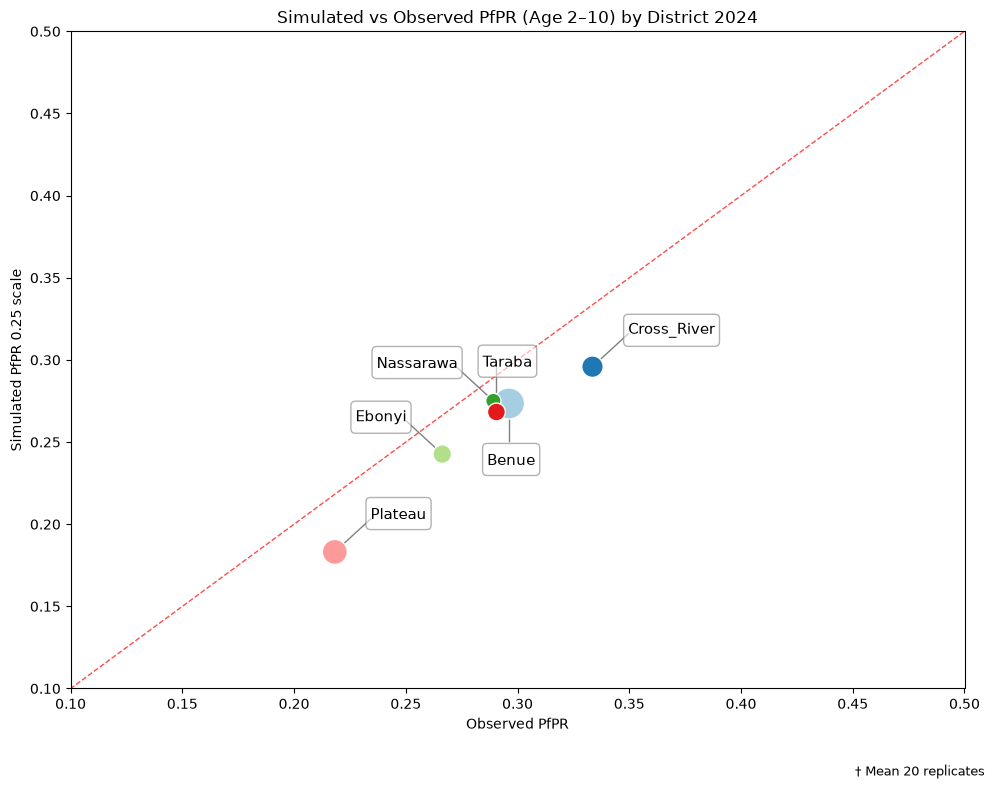

In [47]:
# ======================================================
# Figure 1: Simulated vs Observed PfPR by District
# ======================================================
fig, ax = plt.subplots(figsize=(10, 8))

d1 = compare_data[["average_OBSERVED_prevalence_2_to_10_through_calibration_year", "average_simulated_prevalence_2_to_10_through_calibration_year", "State", "average_simulated_population_through_calibration_year"]].dropna(
    subset=["average_OBSERVED_prevalence_2_to_10_through_calibration_year", "average_simulated_prevalence_2_to_10_through_calibration_year"]
)

sns.scatterplot(
    data=d1,
    x="average_OBSERVED_prevalence_2_to_10_through_calibration_year",
    y="average_simulated_prevalence_2_to_10_through_calibration_year",
    hue="State",
    size="average_simulated_population_through_calibration_year",  
    sizes=(120, 500),
    palette="Paired",
    ax=ax,
    legend=False
)

sc = ax.collections[0] if ax.collections else None

''' Use full range when trying to calibrate pipeline, narrow range yields better looking plots when finalized'''

# ax.set_xlim(0.0, 1.0)
# ax.set_ylim(0.0, 1.0)
ax.set_xlim(0.1, 0.5)
ax.set_ylim(0.1, 0.5)

span = min(ax.get_xlim()[1] - ax.get_xlim()[0], ax.get_ylim()[1] - ax.get_ylim()[0])

texts = d1["State"].astype(str).fillna("").tolist()
x = d1["average_OBSERVED_prevalence_2_to_10_through_calibration_year"].to_numpy(dtype=float)
y = d1["average_simulated_prevalence_2_to_10_through_calibration_year"].to_numpy(dtype=float)

allocate(
    ax,
    x,
    y,
    texts,
    scatter_plot=sc,
    textsize=11,
    draw_lines=True,
    linecolor="gray",
    textcolor="black",
    margin=0.02,
    min_distance=0.10 * span,
    max_distance=0.35 * span,
    nbr_candidates=3000,
    verbose=False,
    linespacing=1.5,   
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="gray",
        alpha=0.6,
    ),
)

ax.plot([0.0, 1.0], [0.0, 1.0], linestyle="--", linewidth=1, color="red", alpha=0.7)
ax.set_title(f"Simulated vs Observed PfPR (Age 2–10) by District {calibration_year}")
ax.set_xlabel("Observed PfPR")
ax.set_ylabel(f"Simulated PfPR {population_scale_from_input_yml} scale")

plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.text(0.99, 0.02, f"$\dagger$ Mean {validation_replicates} replicates",
          ha='right', va='bottom', fontsize=9)
plt.savefig(f"{analysis_path}/Simulated_vs_Observed_PfPR_by_District_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()

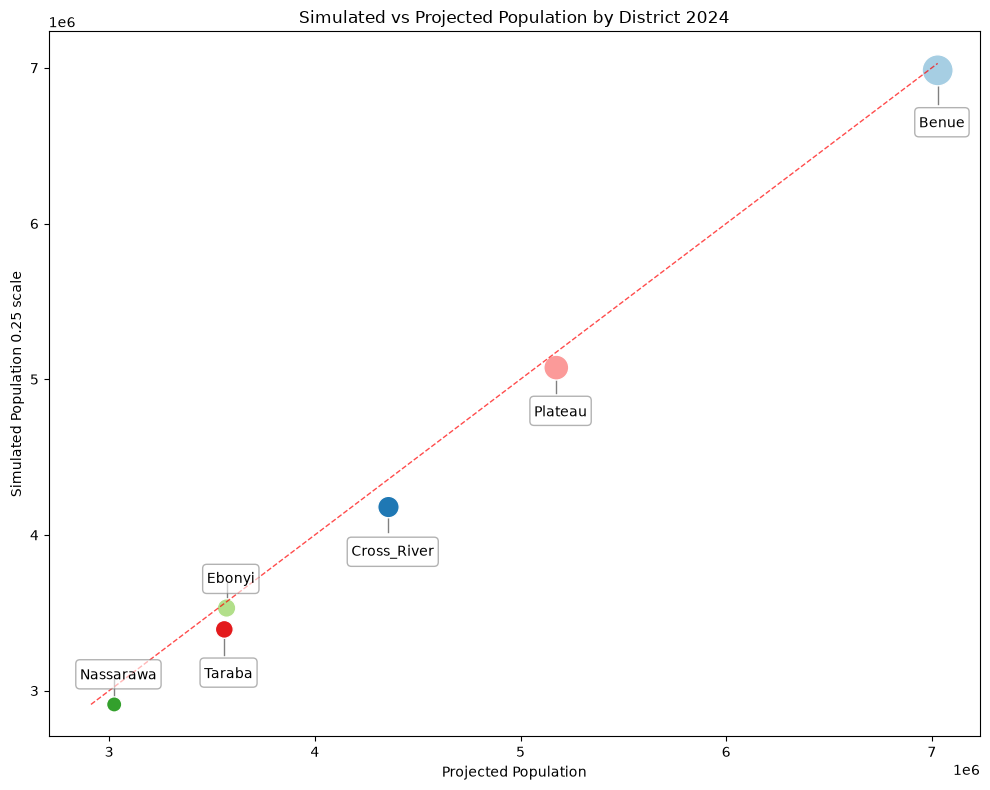

In [48]:
# ======================================================
# Figure 2: Simulated vs Projected Population by District
# ======================================================
fig, ax = plt.subplots(figsize=(10, 8))

d2 = compare_data[["population_projected_calibration_year", "average_simulated_population_through_calibration_year", "State"]].dropna(
    subset=["population_projected_calibration_year", "average_simulated_population_through_calibration_year"]
)

sns.scatterplot(
    data=d2,
    x="population_projected_calibration_year",
    y="average_simulated_population_through_calibration_year",
    hue="State",
    size="average_simulated_population_through_calibration_year",
    sizes=(120, 500),
    palette="Paired",
    ax=ax,
    legend=False
)

sc = ax.collections[0] if ax.collections else None

texts = d2["State"].astype(str).fillna("").tolist()
x = d2["population_projected_calibration_year"].to_numpy(dtype=float)
y = d2["average_simulated_population_through_calibration_year"].to_numpy(dtype=float)

allocate(
    ax,
    x,
    y,
    texts,
    scatter_plot=sc,
    textsize=10,
    draw_lines=True,
    linecolor="gray",
    textcolor="black",
    margin=0.01,
    min_distance=0.01,
    max_distance=0.08,
    nbr_candidates=300,
    verbose=False,
    linespacing=1.5,   
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="gray",
        alpha=0.6,
    ),
)

min_val = min(d2["population_projected_calibration_year"].min(), d2["average_simulated_population_through_calibration_year"].min())
max_val = max(d2["population_projected_calibration_year"].max(), d2["average_simulated_population_through_calibration_year"].max())
ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1, color="red", alpha=0.7)

ax.set_title(f"Simulated vs Projected Population by District {calibration_year}")
ax.set_xlabel("Projected Population")
ax.set_ylabel(f"Simulated Population {population_scale_from_input_yml} scale")

plt.tight_layout()
plt.savefig(f"{analysis_path}/Simulated_vs_Projected_Population_by_District_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()

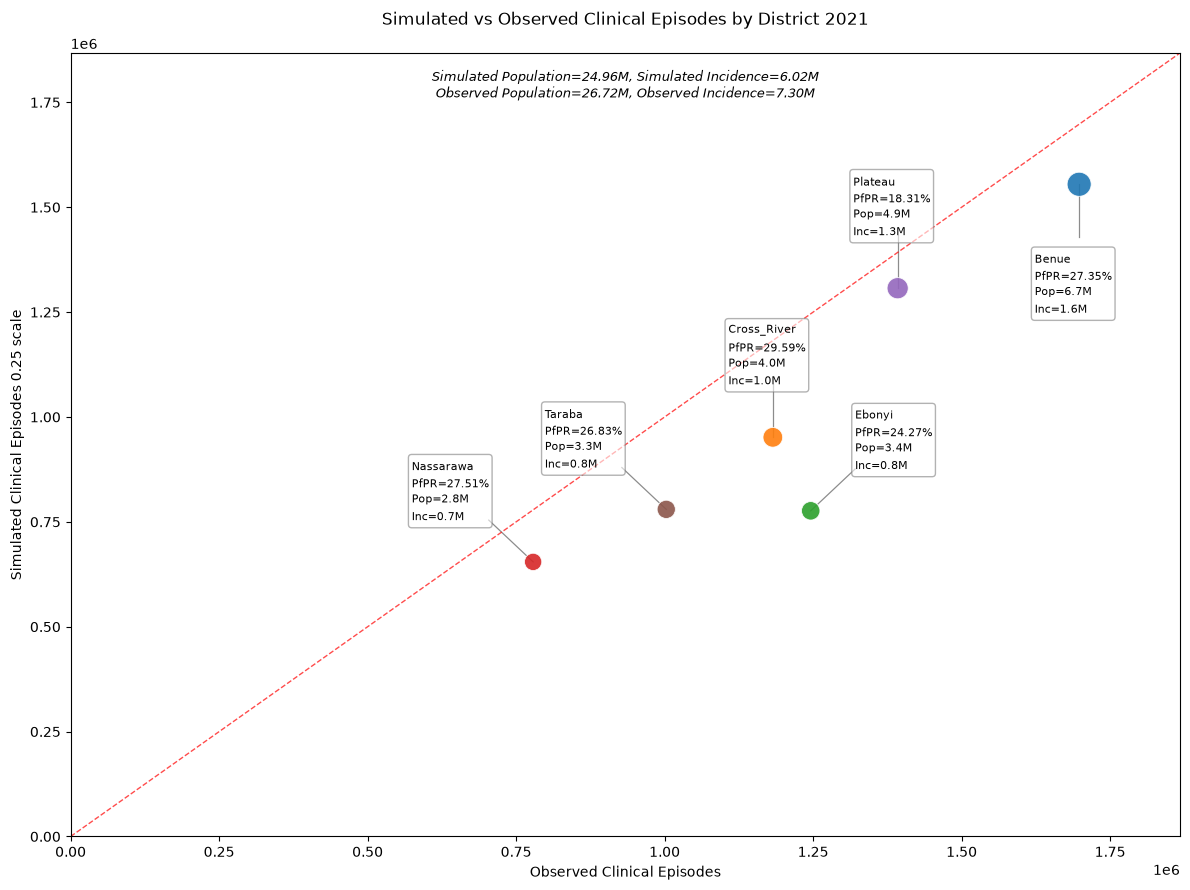

In [49]:
# ======================================================
# Figure 3: Simulated vs Observed Clinical Episodes by District
# ======================================================
fig, ax = plt.subplots(figsize=(12, 9))

d4 = compare_data[
    [
        "annual_OBSERVED_clinical_episodes_incidence_comparison_year",
        "simulated_public_clinical_episodes",
        "average_simulated_population_through_incidence_comparison_year",
        "State",
        "average_simulated_prevalence_2_to_10_through_calibration_year",
        "population_projected_calibration_year"
    ]
].dropna(
    subset=[
        "annual_OBSERVED_clinical_episodes_incidence_comparison_year",
        "simulated_public_clinical_episodes",
        "average_simulated_population_through_incidence_comparison_year",
        "average_simulated_prevalence_2_to_10_through_calibration_year",
        "population_projected_calibration_year"
    ]
).copy()

x = d4["annual_OBSERVED_clinical_episodes_incidence_comparison_year"].to_numpy(float)
# y = d4["mean_clinical_episodes_sim"].to_numpy(float)
y = d4["simulated_public_clinical_episodes"].to_numpy(float)

pop = d4["average_simulated_population_through_incidence_comparison_year"].to_numpy(float)
sizes = (pop / pop.max()) * 250.0 + 50.0

total_pop_sim = d4["average_simulated_population_through_incidence_comparison_year"].sum()
# total_clinical_episodes_sim = d4["mean_clinical_episodes_sim"].sum()
total_clinical_episodes_sim = d4["simulated_public_clinical_episodes"].sum()
total_pop_obs = d4["population_projected_calibration_year"].sum()
total_clinical_episodes_obs = d4["annual_OBSERVED_clinical_episodes_incidence_comparison_year"].sum()

texts = []
for _, row in d4.iterrows():
    name = str(row["State"])
    pfpr = row["average_simulated_prevalence_2_to_10_through_calibration_year"]
    population = row["average_simulated_population_through_incidence_comparison_year"]
    # cases = row["mean_clinical_episodes_sim"]
    cases = row["simulated_public_clinical_episodes"]
    label = f"{name}\nPfPR={pfpr*100:.2f}%\nPop={population/1e6:.1f}M\nInc={cases/1e6:.1f}M"
    texts.append(label)

districts = d4["State"].astype(str).tolist()
palette = sns.color_palette("tab10", n_colors=len(districts))
color_map = {name: palette[i] for i, name in enumerate(districts)}
colors = [color_map[name] for name in districts]

sc = ax.scatter(
    x, y,
    s=sizes,
    c=colors,
    alpha=0.9,
    edgecolors="white",
    linewidths=0.6,
    zorder=2,
)

maxv = max(np.nanmax(x), np.nanmax(y)) * 1.10
ax.set_xlim(0, maxv)
ax.set_ylim(0, maxv)

linecolor = [(0, 0, 0, 0.45)] * len(x)

allocate(
    ax, x, y, texts,
    scatter_plot=sc,
    textsize=8,
    draw_lines=True,
    draw_all=True,
    linecolor=linecolor,
    linewidth=0.9,
    margin=0.03,
    min_distance=0.04,
    max_distance=0.38,
    nbr_candidates=5000,
    verbose=False,
    linespacing=1.5,   
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="gray",
        alpha=0.6,
    ),
)

ax.plot(ax.get_xlim(), ax.get_ylim(), color="red", linestyle="--", linewidth=1, zorder=1, alpha=0.7)
ax.set_xlabel("Observed Clinical Episodes")
ax.set_ylabel(f"Simulated Clinical Episodes {population_scale_from_input_yml} scale")
ax.set_title(
    f"Simulated vs Observed Clinical Episodes by District {incidence_comparison_year}\n"
)

ax.text(
    0.5, 0.98,
    f"Simulated Population={total_pop_sim/1e6:.2f}M, Simulated Incidence={total_clinical_episodes_sim/1e6:.2f}M\n"
    f"Observed Population={total_pop_obs/1e6:.2f}M, Observed Incidence={total_clinical_episodes_obs/1e6:.2f}M",
    transform=ax.transAxes,
    fontsize=9, color="black", style="italic",
    ha="center", va="top"
)

plt.tight_layout()
plt.savefig(f"{analysis_path}/Simulated_vs_Observed_Clinical_Episodes_{incidence_comparison_year}.png", dpi=200, bbox_inches="tight")
plt.show()

In [50]:
d4

,annual_OBSERVED_clinical_episodes_incidence_comparison_year,simulated_public_clinical_episodes,average_simulated_population_through_incidence_comparison_year,State,average_simulated_prevalence_2_to_10_through_calibration_year,population_projected_calibration_year
0,1697829,1554705,6667394,Benue,0,7028225
1,1182153,951516,4010236,Cross_River,0,4358119
2,1245948,776329,3369310,Ebonyi,0,3570786
3,778632,654571,2795522,Nassarawa,0,3024446
4,1392289,1306962,4852603,Plateau,0,5174011
5,1002734,779831,3263529,Taraba,0,3559850


In [51]:
# # ======================================================
# # Figure 4: Simulated vs Observed PfPR difference by district
# # ======================================================
# fig, ax = plt.subplots(figsize=(12, 8))

# d3 = compare_data.copy()
# d3["diff"] = d3["mean_2_to_10_sim"] - d3["mean_2_to_10_obs"]
# d3 = d3.sort_values("diff")

# colors = ["red" if d > 0 else "blue" for d in d3["diff"]]

# ax.bar(d3["State"].astype(str), d3["diff"], color=colors)
# ax.axhline(0, color="black", linewidth=1)

# ax.set_xlabel("District")
# ax.set_ylabel("PfPR difference (Simulated - Observed)")
# ax.set_title(f"Simulated vs Observed PfPR Difference by District {incidence_comparison_year}")
# ax.tick_params(axis="x", rotation=45)

# plt.tight_layout()
# plt.savefig(f"{analysis_path}/Simulated_vs_Observed_PfPR_Difference_by_District_{incidence_comparison_year}.png", dpi=200, bbox_inches="tight")
# plt.show()